# EDA — Predicting Irrigation Need (PS S6E4)

**Target:** `Irrigation_Need` (Low / Medium / High)  
**Metric:** balanced accuracy  
**Train:** 630,000 rows · **Test:** 270,000 rows · **Features:** 19 (8 categorical + 11 numeric)

## Headline findings
1. **Severe imbalance**: Low 58.7% / Medium 38.0% / **High 3.3%**. Balanced accuracy will be dominated by how well we recover the High class.
2. **No missing values** anywhere in train or test.
3. **Train and test distributions are essentially identical** (mean diffs < 0.01 σ). No covariate shift, no need for adversarial validation.
4. **All categoricals are low cardinality** (2–6 levels) with no unseen categories in test → label-encoding is fine.
5. **Top predictive features** (large effect on High class):
   - `Crop_Growth_Stage`: Flowering/Vegetative ≈ 6.4% High vs Harvest/Sowing ≈ 0.2% — 30× ratio
   - `Mulching_Used`: No=5.9% vs Yes=0.8%
   - `Soil_Moisture` (low → High), `Temperature_C` (high → High), `Wind_Speed_kmh` (high → High), `Rainfall_mm` (low → High)
6. **Weak signal**: Soil_Type, Crop_Type, Season, Region, Water_Source, Irrigation_Type, Organic_Carbon, Soil_pH, Humidity, Sunlight_Hours, Field_Area, Previous_Irrigation_mm, Electrical_Conductivity (≤ 0.005 spread across classes for some).

These are consistent with agronomy: dry soil + hot + windy + low rain + active crop growth + no mulch → high irrigation need.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.paths import TRAIN_CSV, TEST_CSV, TARGET, CATEGORICAL, NUMERIC

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

tr = pd.read_csv(TRAIN_CSV)
te = pd.read_csv(TEST_CSV)
print('Train:', tr.shape, ' Test:', te.shape)
tr.head()

Train: (630000, 21)  Test: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 1. Target balance

In [2]:
order = ['Low', 'Medium', 'High']
counts = tr[TARGET].value_counts().reindex(order)
props  = tr[TARGET].value_counts(normalize=True).reindex(order)
print(pd.DataFrame({'count': counts, 'pct': (props*100).round(2)}))

# Naive baselines for balanced accuracy
from sklearn.metrics import balanced_accuracy_score
y = tr[TARGET]
print('\nBalanced acc, predict Low always:', balanced_accuracy_score(y, ['Low']*len(y)))
print('Balanced acc, predict random uniform:', round(1/3, 4))

                  count    pct
Irrigation_Need               
Low              369917  58.72
Medium           239074  37.95
High              21009   3.33

Balanced acc, predict Low always: 0.3333333333333333
Balanced acc, predict random uniform: 0.3333


## 2. Missing values & dtypes

In [3]:
print('Missing in train:', int(tr.isna().sum().sum()))
print('Missing in test :', int(te.isna().sum().sum()))
tr.dtypes

Missing in train: 0
Missing in test : 0


id                           int64
Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str
Previous_Irrigation_mm     float64
Region                         str
Irrigation_Need                str
dtype: object

## 3. Categorical cardinalities & test-vs-train levels

In [4]:
rows = []
for c in CATEGORICAL:
    tr_set = set(tr[c].unique())
    te_set = set(te[c].unique())
    rows.append({
        'feature': c,
        'n_train': len(tr_set),
        'n_test': len(te_set),
        'unseen_in_test': sorted(te_set - tr_set),
        'levels': sorted(tr_set),
    })
pd.DataFrame(rows)

,feature,n_train,n_test,unseen_in_test,levels
0,Soil_Type,4,4,[],"[Clay, Loamy, Sandy, Silt]"
1,Crop_Type,6,6,[],"[Cotton, Maize, Potato, Rice, Sugarcane, Wheat]"
2,Crop_Growth_Stage,4,4,[],"[Flowering, Harvest, Sowing, Vegetative]"
3,Season,3,3,[],"[Kharif, Rabi, Zaid]"
4,Irrigation_Type,4,4,[],"[Canal, Drip, Rainfed, Sprinkler]"
5,Water_Source,4,4,[],"[Groundwater, Rainwater, Reservoir, River]"
6,Mulching_Used,2,2,[],"[No, Yes]"
7,Region,5,5,[],"[Central, East, North, South, West]"


## 4. Numeric describe + train/test drift

In [5]:
describe_tr = tr[NUMERIC].describe().T
describe_tr

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


In [6]:
drift = pd.DataFrame({
    'train_mean': tr[NUMERIC].mean(),
    'test_mean':  te[NUMERIC].mean(),
    'train_std':  tr[NUMERIC].std(),
    'test_std':   te[NUMERIC].std(),
})
drift['mean_diff_in_sigmas'] = (drift.test_mean - drift.train_mean) / drift.train_std
drift.round(4)

,train_mean,test_mean,train_std,test_std,mean_diff_in_sigmas
Soil_pH,6.4825,6.4809,0.9225,0.9222,-0.0017
Soil_Moisture,37.3045,37.3076,16.3771,16.3753,0.0002
Organic_Carbon,0.9229,0.9223,0.3658,0.3658,-0.0016
Electrical_Conductivity,1.7446,1.7453,0.9523,0.9513,0.0007
Temperature_C,26.9982,27.0017,8.6236,8.6307,0.0004
Humidity,61.5632,61.5113,19.7082,19.6903,-0.0026
Rainfall_mm,1462.2076,1464.5259,612.9897,612.5217,0.0038
Sunlight_Hours,7.5134,7.5133,1.9993,2.0027,-0.0001
Wind_Speed_kmh,10.3754,10.3865,5.6895,5.6832,0.0020
Field_Area_hectare,7.5177,7.5082,4.2181,4.2187,-0.0023


## 5. Conditional class rates per categorical

In [7]:
for c in CATEGORICAL:
    g = (tr.groupby(c)[TARGET]
           .value_counts(normalize=True)
           .unstack(fill_value=0)[order]
           .sort_values('High', ascending=False))
    print(f'\n=== {c} ===')
    print(g.round(4))


=== Soil_Type ===
Irrigation_Need     Low  Medium    High
Soil_Type                              
Sandy            0.5763  0.3850  0.0387
Clay             0.5870  0.3780  0.0351
Silt             0.5868  0.3829  0.0303
Loamy            0.5993  0.3719  0.0288

=== Crop_Type ===
Irrigation_Need     Low  Medium    High
Crop_Type                              
Maize            0.5701  0.3877  0.0422
Sugarcane        0.5929  0.3680  0.0392
Cotton           0.5872  0.3767  0.0361
Wheat            0.5965  0.3718  0.0317
Potato           0.5759  0.3967  0.0274
Rice             0.5999  0.3768  0.0234

=== Crop_Growth_Stage ===
Irrigation_Need       Low  Medium    High
Crop_Growth_Stage                        
Flowering          0.3060  0.6296  0.0644
Vegetative         0.3238  0.6121  0.0641
Harvest            0.8479  0.1489  0.0032
Sowing             0.8718  0.1265  0.0016

=== Season ===
Irrigation_Need     Low  Medium    High
Season                                 
Kharif           0.5713  0.

## 6. Numeric per-class means + overlap

In [8]:
by_class = tr.groupby(TARGET)[NUMERIC].agg(['mean','std']).T
by_class

Irrigation_Need                     High          Low       Medium
Soil_pH                 mean    6.578282     6.487805     6.465867
                        std     0.978948     0.916681     0.925763
Soil_Moisture           mean   17.669875    43.305902    29.743961
                        std     7.479613    13.421279    16.624592
Organic_Carbon          mean    0.924143     0.920680     0.926116
                        std     0.373870     0.365927     0.364882
Electrical_Conductivity mean    1.690880     1.731755     1.769208
                        std     0.891465     0.961384     0.942780
Temperature_C           mean   34.568134    25.347708    28.886683
                        std     5.420716     8.364835     8.503269
Humidity                mean   61.119576    61.949194    61.004887
                        std    19.242509    19.913072    19.413552
Rainfall_mm             mean  989.156678  1500.534313  1444.475028
                        std   800.312437   584.804731   618.449689
Sunlight_Hours          mean    7.463138     7.511125     7.521290
                        std     2.030893     2.000223     1.995064
Wind_Speed_kmh          mean   14.642639     9.216424    11.793668
                        std     4.118403     5.632220     5.388586
Field_Area_hectare      mean    7.530391     7.447241     7.625725
                        std     4.476655     4.197295     4.224577
Previous_Irrigation_mm  mean   63.053300    61.718330    63.181715
                        std    32.197213    35.548062    32.295011

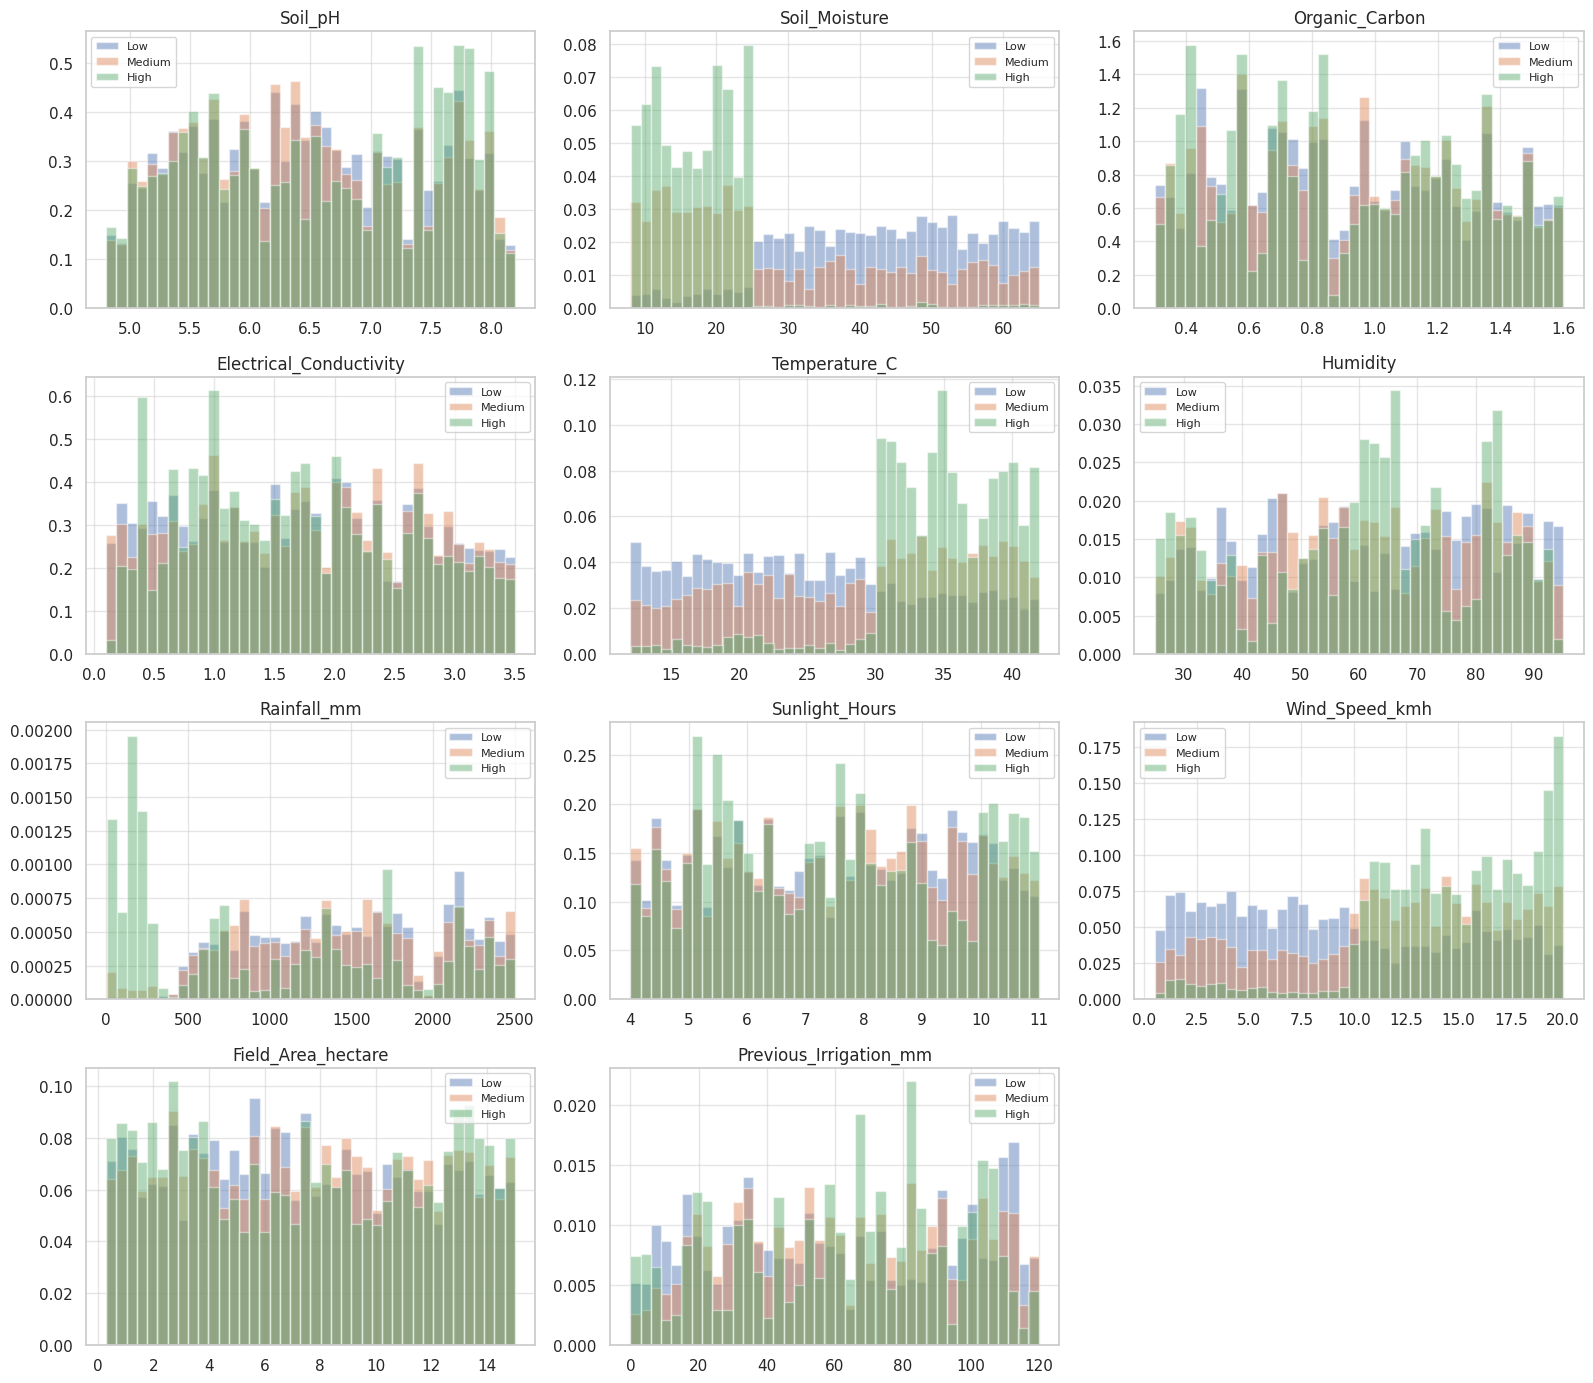

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flat, NUMERIC):
    for cls in order:
        ax.hist(tr.loc[tr[TARGET]==cls, col], bins=40, alpha=0.45, density=True, label=cls)
    ax.set_title(col)
    ax.legend(fontsize=8)
for ax in axes.flat[len(NUMERIC):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Correlations among numerics

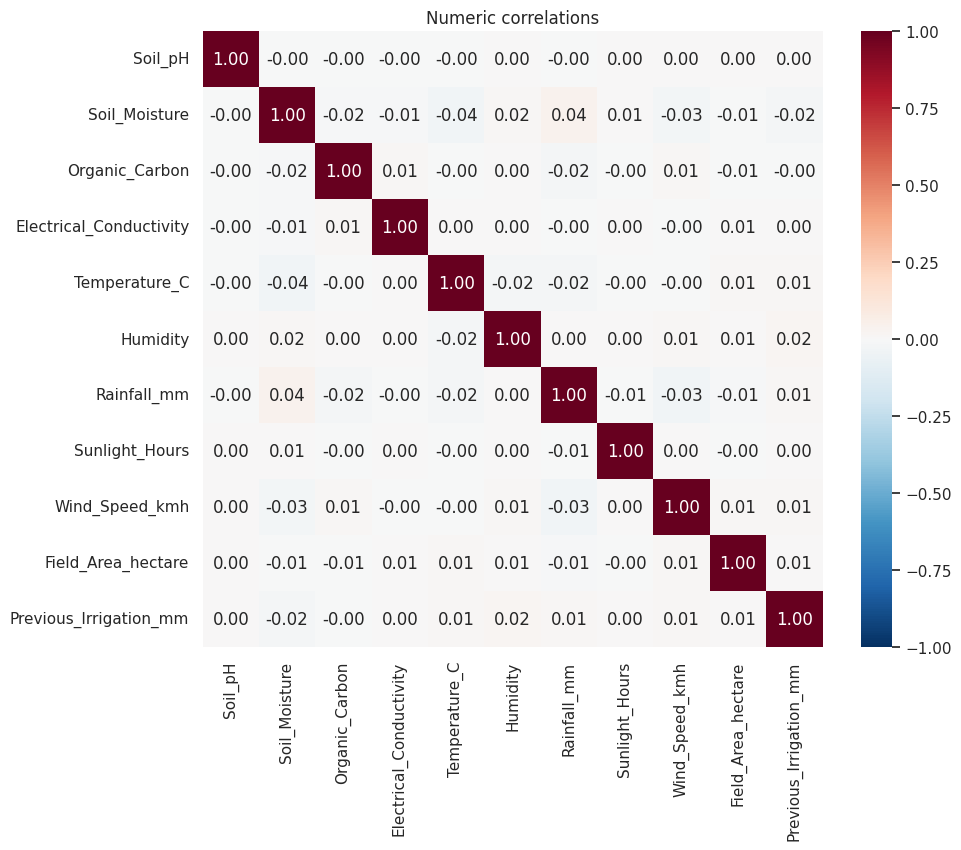

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(tr[NUMERIC].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Numeric correlations')
plt.show()

## 8. Mutual information ranking (quick feature relevance)

In [11]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X = tr.drop(columns=['id', TARGET]).copy()
for c in CATEGORICAL:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))
y = LabelEncoder().fit_transform(tr[TARGET])

# Sample for speed
rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=min(80_000, len(X)), replace=False)
mi = mutual_info_classif(X.iloc[idx], y[idx], discrete_features=[c in CATEGORICAL for c in X.columns], random_state=0)
mi_df = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_df.to_frame('mutual_info').round(4)

,mutual_info
Soil_Moisture,0.2073
Rainfall_mm,0.1898
Crop_Growth_Stage,0.1662
Temperature_C,0.0713
Wind_Speed_kmh,0.0615
Previous_Irrigation_mm,0.0527
Humidity,0.0495
Mulching_Used,0.0479
Field_Area_hectare,0.0132
Organic_Carbon,0.0112


## 9. Implications for modeling

- Use **stratified K-fold** (the 3.3% High class is small enough that random splits could create unstable folds).
- Use `class_weight='balanced'` or `sample_weight` so the High class is not ignored. Tune the weight: `balanced` is a starting point, not necessarily optimal for *balanced accuracy*.
- After predicting probabilities, **tune per-class decision thresholds on OOF preds** to maximize balanced accuracy directly. With this much imbalance and this metric, threshold tuning alone is worth several points.
- **Feature engineering priorities** (grounded in the EDA):
  - Water deficit: `Rainfall_mm - Previous_Irrigation_mm`, `Soil_Moisture / (Rainfall_mm+1)`
  - Evapotranspiration proxy: `Temperature_C * Sunlight_Hours / (Humidity + 1)`
  - Wind/heat stress: `Wind_Speed_kmh * Temperature_C`
  - Active-growth flag: `Crop_Growth_Stage in {Flowering, Vegetative}`
  - Mulch × dryness interaction: `(Mulching_Used == 'No') * (50 - Soil_Moisture)`
  - pH deviation: `abs(Soil_pH - 6.5)`
- **Skip** complex target encoding — categoricals are tiny cardinality so plain label-encoding is enough for tree models, and CatBoost handles them natively.